<a href="https://colab.research.google.com/github/piercegregory-spec/Magician-Corner_Corrected/blob/main/ImageWrangling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell #1
# Copyright (C) Bradley J Erickson and RSNA, 2019

!rm -rf MC-ImageWrangling images nii tmp
!git clone https://github.com/slowvak/MC-ImageWrangling.git

# Unpack tools
!unzip -oq MC-ImageWrangling/Bet-n-dcm2nii.zip

# Prepare folders
!mkdir -p images tmp nii

# Unpack the subject archives
!cd images && unzip -oq ../MC-ImageWrangling/S1-4.zip
!cd images && unzip -oq ../MC-ImageWrangling/S5-8.zip
!cd images && unzip -oq ../MC-ImageWrangling/S9-12.zip
!cd images && unzip -oq ../MC-ImageWrangling/S13-16.zip

NIFTI_PATH = './nii'

import os, fnmatch

# Make sure converter is executable
os.system("chmod +x ./dcm2nii")

for subj in fnmatch.filter(os.listdir('./images'), 'S*'):
    subj_path = os.path.join('./images', subj)

    # only use the expected series if present
    available_series = [s for s in ['T1', 'T2', 'GAD']
                        if os.path.exists(os.path.join(subj_path, s))]

    for ser in available_series:
        # clear tmp before each conversion so you don't pick up old files
        os.system("rm -f ./tmp/*.nii.gz")

        dcm_path = os.path.join(subj_path, ser)
        cmd = f"./dcm2nii -o tmp {dcm_path}"
        os.system(cmd)

        f = fnmatch.filter(os.listdir('./tmp'), '*.nii.gz')
        if not f:
            print(f"Warning: no .nii.gz produced for {dcm_path}")
            continue

        out_dir = os.path.join(NIFTI_PATH, subj)
        os.makedirs(out_dir, exist_ok=True)

        out_path = os.path.join(out_dir, ser + ".nii.gz")
        os.system(f"mv ./tmp/{f[0]} {out_path}")
        print(f"Saved {out_path}")


Cloning into 'MC-ImageWrangling'...
remote: Enumerating objects: 73, done.
remote: Total 73 (delta 0), reused 0 (delta 0), pack-reused 73 (from 1)
Receiving objects: 100% (73/73), 329.35 MiB | 38.82 MiB/s, done.
Resolving deltas: 100% (26/26), done.
Saved ./nii/S6/T1.nii.gz
Saved ./nii/S6/T2.nii.gz
Saved ./nii/S6/GAD.nii.gz
Saved ./nii/S9/T1.nii.gz
Saved ./nii/S9/T2.nii.gz
Saved ./nii/S9/GAD.nii.gz
Saved ./nii/S4/T1.nii.gz
Saved ./nii/S4/T2.nii.gz
Saved ./nii/S4/GAD.nii.gz
Saved ./nii/S5/T1.nii.gz
Saved ./nii/S5/T2.nii.gz
Saved ./nii/S5/GAD.nii.gz
Saved ./nii/S15/T1.nii.gz
Saved ./nii/S15/T2.nii.gz
Saved ./nii/S15/GAD.nii.gz
Saved ./nii/S7/T1.nii.gz
Saved ./nii/S7/T2.nii.gz
Saved ./nii/S7/GAD.nii.gz
Saved ./nii/S8/T1.nii.gz
Saved ./nii/S8/T2.nii.gz
Saved ./nii/S8/GAD.nii.gz
Saved ./nii/S1/T1.nii.gz
Saved ./nii/S1/T2.nii.gz
Saved ./nii/S1/GAD.nii.gz
Saved ./nii/S11/T1.nii.gz
Saved ./nii/S11/T2.nii.gz
Saved ./nii/S11/GAD.nii.gz
Saved ./nii/S13/T1.nii.gz
Saved ./nii/S13/T2.nii.gz
Saved ./

In [ ]:
# CELL #2
# Now do some basic processing to prepare the images
# Note this will take about 30 minutes to complete.
# If you want to skip it, the output is already computed and saved for next cell


# FSL (flirt-the image registration application) complains if this environment variable is not set
os.environ['FSLOUTPUTTYPE'] = 'NIFTI_GZ'

for subj in os.listdir(NIFTI_PATH):
    subj_path = os.path.join(NIFTI_PATH, subj)
    print ("Working on " + subj_path)
    series = fnmatch.filter(os.listdir(subj_path), '*.nii.gz')
    for ser in ['T1', 'T2', 'GAD']:
        nii_file = os.path.join (subj_path, ser)
# First, perform N4 bias correction. Not required, but may improve results. Also must track new names
        new_file = os.path.join (subj_path, 'N4-' + ser)
        cmd = "./N4BiasFieldCorrection -i %s.nii.gz -o %s.nii.gz" % (nii_file, new_file)
        os.system(cmd)
#        print (cmd)
# Next, Register the images to the post-Gad images so skip the GAD
    GAD_file = os.path.join (subj_path, 'N4-GAD.nii.gz')
    T1_file =  os.path.join (subj_path, 'N4-T1.nii.gz')
    new_file = os.path.join (subj_path, 'Reg-T1.nii.gz')
    cmd = "./flirt -in %s -ref %s  -out %s" % (T1_file, GAD_file, new_file)
    os.system(cmd)
#    print (cmd)
    T2_file =  os.path.join (subj_path, 'N4-T2.nii.gz')
    new_file = os.path.join (subj_path, 'Reg-T2.nii.gz')
    cmd = "./flirt -in %s -ref %s  -out %s" % (T2_file, GAD_file, new_file)
    os.system(cmd)
#    print (cmd)
# can also try to mask out non-brain tissue, but that doesn't work as well on thick slice MRI
# first, compute the mask.
#    cmd = "./bet2 %s.nii.gz %s.nii.gz" % (os.path.join (subj_path, 'Reg-T1'), os.path.join (subj_path, 'mask'))
#    os.system(cmd)
#    cmd = "./fslmaths %s.nii.gz -mas %s.nii.gz %s.nii.gz" % (os.path.join (subj_path, 'Reg-T1'), os.path.join (subj_path, 'mask'), os.path.join (subj_path, 'Reg-T1'))
#    os.system(cmd)
#    cmd = "./fslmaths %s.nii.gz -mas %s.nii.gz %s.nii.gz" % (os.path.join (subj_path, 'Reg-T2'), os.path.join (subj_path, 'mask'), os.path.join (subj_path, 'Reg-T2'))
#    os.system(cmd)
#    cmd = "./fslmaths %s.nii.gz -mas %s.nii.gz %s.nii.gz" % (os.path.join (subj_path, 'N4-GAD'), os.path.join (subj_path, 'mask'), os.path.join (subj_path, 'N4-GAD'))

# finally, copy over original so you can skip these steps if you like
    cmd = "cp %s.nii.gz %s.nii.gz" % (os.path.join (subj_path, 'Reg-T1'), os.path.join (subj_path, 'T1'))
    os.system(cmd)
    cmd = "cp %s.nii.gz %s.nii.gz" % (os.path.join (subj_path, 'Reg-T2'), os.path.join (subj_path, 'T2'))
    os.system(cmd)
    cmd = "cp %s.nii.gz %s.nii.gz" % (os.path.join (subj_path, 'N4-GAD'), os.path.join (subj_path, 'GAD'))
    os.system(cmd)

#!ls -l ./nii/S1


Working on ./nii/S6
Working on ./nii/S9
Working on ./nii/S4
Working on ./nii/S5
Working on ./nii/S15
Working on ./nii/S7
Working on ./nii/S8
Working on ./nii/S1
Working on ./nii/S11
Working on ./nii/S13
Working on ./nii/S14
Working on ./nii/S16
Working on ./nii/S3
Working on ./nii/S10
Working on ./nii/S2
Working on ./nii/S12


In [ ]:
# Cell #3

# This unzips known good files processed as above.
# skip this cell if you want to use your version

for subj in ['S1-4', 'S5-8', 'S9-12', 'S13-16']:
    cmd = 'cd ./nii; unzip -q ../%s.zip .' % (subj)
    os.system(cmd)
# must also delete the DICOM and intermediate files to have enough space to make the new files
!rm -rf nii/Reg*
!rm -rf nii/N4-*
!rm -rf ./images



# At this point, we have nifti files (T1.nii.gz, T2.nii.gz, GAD.nii.gz) for each subject


In [ ]:
#Cell #3a
!find . -name "TumorSlices.csv"

./TumorSlices.csv
./MC-ImageWrangling/TumorSlices.csv


In [ ]:
# Cell #4

# There is also a text file called 'TumorSlices.csv' that I created which has subject ID,
# first slice with contrast enhancement and last slice with contrast enhancement.
# note that subjects 2 and 14 don't have much enhancement
# we will read this into a Pandas dataframe
# Pandas is very popular for data analysis, and has a built-in function to read CSV (and excel) files
import pandas as pd

df = pd.read_csv('./MC-ImageWrangling/TumorSlices.csv')
print(df.head())

!ls -l ./TumorSlices.csv ./MC-ImageWrangling/TumorSlices.csv

  Subject  StartSlice  EndSlice
0      S1          11        18
1      S2           7         8
2      S3          12        15
3      S4          12        18
4      S5           8        13
-rw-r--r-- 1 root root 187 Apr 17 19:17 ./MC-ImageWrangling/TumorSlices.csv
-rw-r--r-- 1 root root   0 Apr 17 19:40 ./TumorSlices.csv


In [ ]:
# Cell #5
# create new versions of the T1, GAD, and T2 images that range from 0 to 255, and where the 0 intensity value maps to the 5th percentile value
# and 255 maps to the 95th percentile value.
import imageio
import nibabel as nib
import numpy as np

MIN_MR = 20

def rescale_5_95_percentile(image):
    dims = np.shape(image)
    image_1d = image.reshape(1, image.size)
    above = np.where(image_1d>MIN_MR, image_1d, image_1d)
    if above.size < image_1d.size/2:
        above = image_1d # avoid bad MIN_MR thresholds
    sorted_im = np.sort(above, axis = None)

    start = int(sorted_im.size / 20)  # 20 = 5%
    end = int(sorted_im.size * 19 / 20) # 95%
    start_val = sorted_im[start]
    end_val = sorted_im[end]

    image = np.maximum(image, start_val) # map values below the start_val to start_val
    image = np.minimum(image, end_val)   # map values above the end_val to end_val
    image = image - start_val # subtract the starting intensity

 #   print ("rescaling range " + str(newmin) + " to " + str(histo[1][index]))
    image = (np.maximum(image, 0) / image.max()) * 255.0
    return image

def nifti_to_img(red_file, green_file, blue_file, not_dir, yes_dir, startSlice, endSlice, subject):
### red_ green_ and blue_files are the nifit files that will be combined to go into the PNG
### not_dir is the direcotry where PNGs are stored if they are not in the (inclusive)
### range set by startSlice/endSlice
### yes_dir is where they are stored when they ARE in the range
### subject is the ID so that we can track where images came from

    try:
        nifti = nib.load(red_file)
        nif_header = nifti.header
        red_image = nifti.get_fdata()
    except:
        return 0

    try:
        if os.path.isfile(green_file):
            nifti = nib.load(green_file)
            nif_header = nifti.header
            green_image = nifti.get_fdata()
        else:
            pass
    except:  # if can't load, then use red image
        green_image = red_image

    try:
        if os.path.isfile(blue_file):
            nifti = nib.load(blue_file)

            nif_header = nifti.header
            blue_image = nifti.get_fdata()
        else:
            pass
    except:  # if can't load, then use red image
        blue_image = red_image

# now scale the intensity for each image
    red_image = rescale_5_95_percentile(red_image)
    green_image = rescale_5_95_percentile(green_image)
    blue_image = rescale_5_95_percentile(blue_image)
# then convert to 8 bits
    red_image = red_image.astype(np.uint8)
    green_image = green_image.astype(np.uint8)
    blue_image = blue_image.astype(np.uint8)

# get the number of slices
    dims = np.shape(red_image)
    zd = dims[2]

    for z in range(0, zd):
        outname = subject + "-{0:04d}".format(z) + '.png'
        if z >= startSlice and z <= endSlice:  # this is enhancing
            out_dir = yes_dir
        else:
            out_dir = not_dir
        outname = os.path.join(out_dir, outname)
        if not os.path.exists(out_dir):
            os.makedirs(out_dir)
        combined = np.dstack((red_image[:,:,z],green_image[:,:,z],
                              blue_image[:,:,z]))
## . images come in rotated
        combined = np.rot90(combined, k=1)
#        print ('Name: ' + outname)
        imageio.imwrite(outname, combined)
    return zd



In [ ]:
# Cell #6
# take the GAD nii, scale it to 0-255 and store that into the red channel
# same for T1 (green) and T2 (blue)
# PNG files are stored in enh / nonenh folders based on the csv file

# store the png files into enhancing or nonenhancing folders after making sure they are cleared

!rm -rf classified

!mkdir classified

for subj in os.listdir(NIFTI_PATH):
    subj_path = os.path.join(NIFTI_PATH, subj)
    red_f = os.path.join(subj_path, 'GAD.nii.gz')
    green_f = os.path.join(subj_path, 'T1.nii.gz')
    blue_f = os.path.join(subj_path, 'T2.nii.gz')
    startSlice = df.loc[df.Subject == subj, 'StartSlice'].values[0]
    endSlice = df.loc[df.Subject == subj, 'EndSlice'].values[0]
    print ("Making PNG file for " + subj + " start: " + str(startSlice) + " end: " + str(endSlice))
    count = nifti_to_img(red_f, green_f, blue_f, './classified/not', './classified/enh', startSlice, endSlice, subj)


Making PNG file for S6 start: 10 end: 17
Making PNG file for S9 start: 7 end: 12
Making PNG file for S4 start: 12 end: 18
Making PNG file for S5 start: 8 end: 13
Making PNG file for S15 start: 11 end: 15
Making PNG file for S7 start: 14 end: 21
Making PNG file for S8 start: 11 end: 18
Making PNG file for S1 start: 11 end: 18
Making PNG file for S11 start: 10 end: 19
Making PNG file for S13 start: 10 end: 17
Making PNG file for S14 start: 7 end: 11
Making PNG file for S16 start: 10 end: 16
Making PNG file for S3 start: 12 end: 15
Making PNG file for S10 start: 9 end: 15
Making PNG file for S2 start: 7 end: 8
Making PNG file for S12 start: 7 end: 11


['enh', 'not']
Train size: 297
Valid size: 74


epoch,train_loss,valid_loss,error_rate,time
0,1.044528,0.595880,0.189189,00:00


epoch,train_loss,valid_loss,error_rate,time
0,0.747853,1.050302,0.418919,00:00
1,0.740288,1.425252,0.459459,00:00
2,0.649224,1.188214,0.364865,00:00
3,0.672017,1.099019,0.324324,00:00
4,0.628978,0.807316,0.256757,00:00


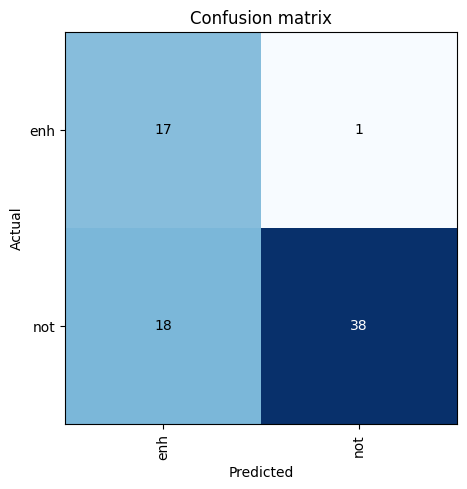

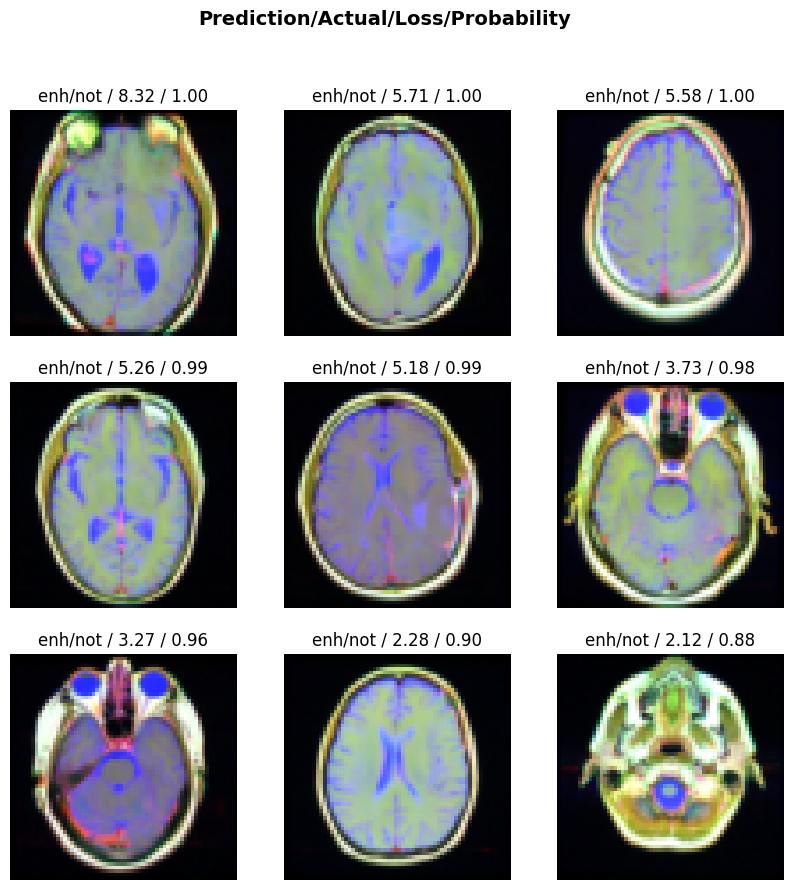

In [ ]:
# Cell #7
# now we are ready to load data and train classifier
# while we did this in separate cells before, we will do it all in one
# this should look familiar.
# Cell 7 -- fastai v2 version
!pip install -q fastai

from fastai.vision.all import *
import numpy as np

classes_dir = "./classified"
np.random.seed(42)

dls = ImageDataLoaders.from_folder(
    classes_dir,
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(64),
    batch_tfms=[*aug_transforms(size=64), Normalize.from_stats(*imagenet_stats)],
    num_workers=4
)

print(dls.vocab)
print(f"Train size: {len(dls.train_ds)}")
print(f"Valid size: {len(dls.valid_ds)}")

learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(5)

interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
interp.plot_top_losses(9, figsize=(10,10))

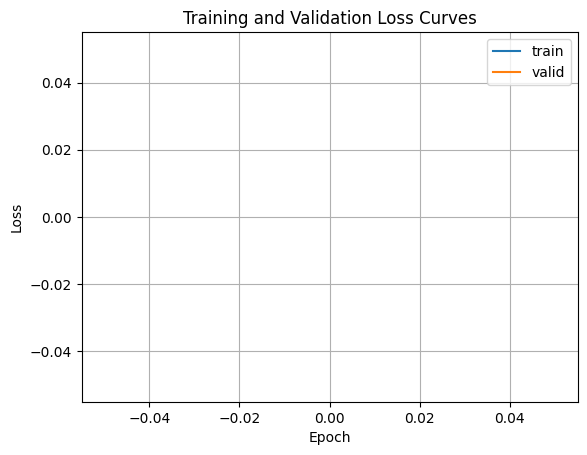

In [ ]:
#Cell 8

import matplotlib.pyplot as plt

# Plot the training and validation loss curves
learn.recorder.plot_loss()
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

<div></div>

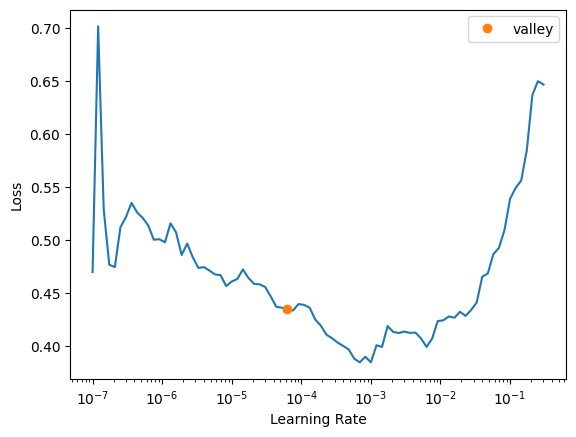

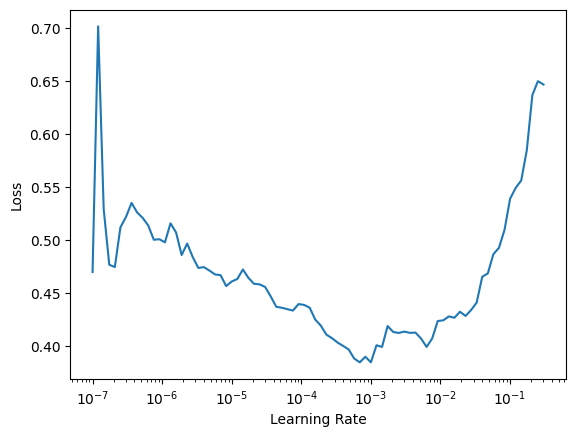

In [ ]:
# Cell #9--Find a good learning rate
learn.lr_find()
learn.recorder.plot_lr_find()

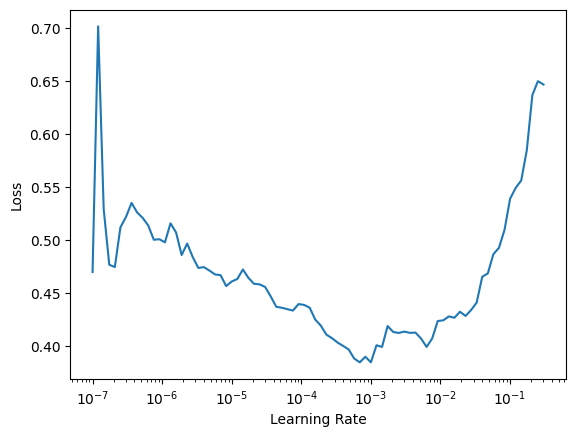

In [ ]:
#Cell 10

learn.recorder.plot_lr_find()

In [ ]:
# Cell 11--Unfreeze all layers for fine-tuning
learn.unfreeze()

# Fine-tune the model with a new learning rate (e.g., 1e-4) for a few epochs
learn.fit_one_cycle(10, lr_max=1e-4)

epoch,train_loss,valid_loss,error_rate,time
0,0.433116,0.678100,0.216216,00:01
1,0.423462,0.679563,0.229730,00:01
2,0.421109,0.655190,0.175676,00:01
3,0.400409,0.586968,0.189189,00:01
4,0.385188,0.520252,0.162162,00:01
5,0.366316,0.487271,0.121622,00:01
6,0.352444,0.448275,0.108108,00:01
7,0.332823,0.416267,0.094595,00:01
8,0.313505,0.391349,0.108108,00:01
9,0.300921,0.342986,0.108108,00:01


### Predict classification results on the validation set for visual inspection

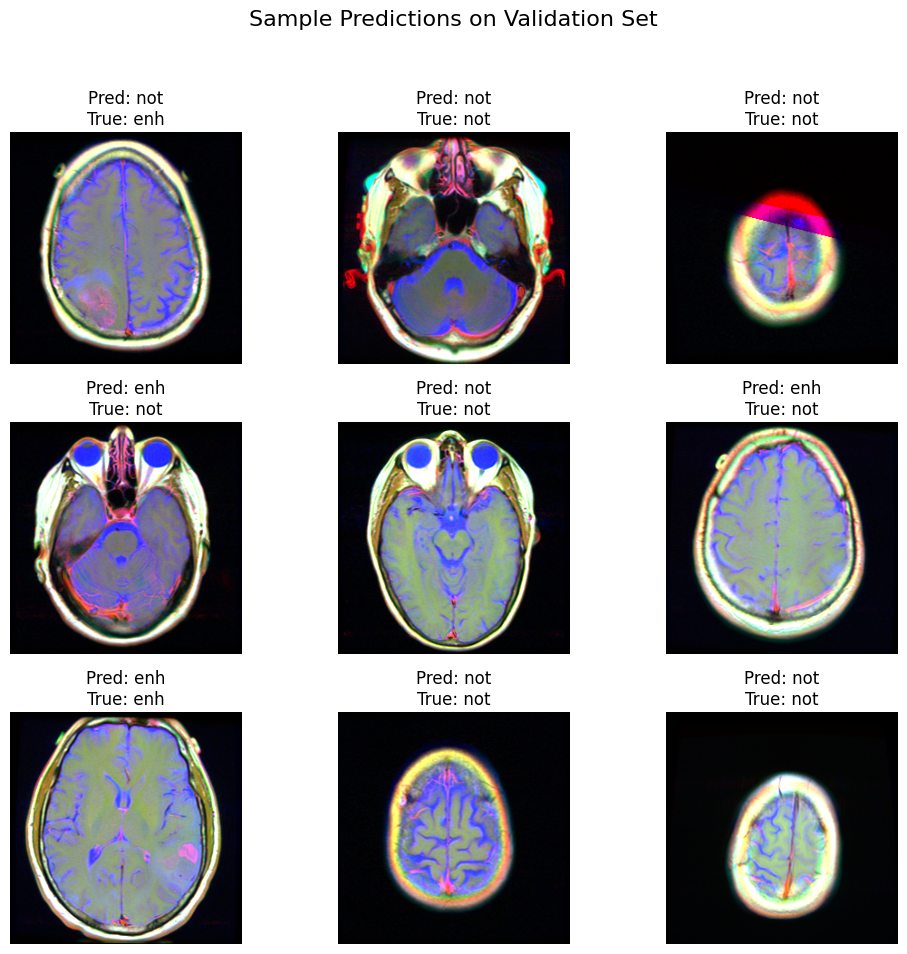

In [ ]:
# Cell 12
# Clean fastai v2 version of Cell 12

from fastai.vision.all import *
import matplotlib.pyplot as plt
import numpy as np

# Get predictions on validation set
preds, targs = learn.get_preds()
pred_classes = preds.argmax(dim=1)

# Access validation dataset directly
dl = learn.dls.valid
vocab = learn.dls.vocab

rows, cols = 3, 3
fig, axes = plt.subplots(rows, cols, figsize=(10,10))
fig.suptitle('Sample Predictions on Validation Set', fontsize=16)

for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(dl.dataset))

    img, true_label = dl.dataset[idx]
    pred_label = pred_classes[idx]

    true_label = vocab[true_label]
    pred_label = vocab[pred_label]

    img.show(ax=ax, title=f'Pred: {pred_label}\nTrue: {true_label}')
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Save the fine-tuned model

In [ ]:
# Cell 13
#Save the fine-tuned model
learn.export('tumor_classification_model.pkl')

print("Model saved successfully to 'tumor_classification_model.pkl'")

Model saved successfully to 'tumor_classification_model.pkl'
